In [1]:
import random
import gym
import numpy as np
import collections
from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import rl_utils

# 经验回放

护一个回放缓冲区，将每次从环境中采样得到的四元组数据（状态、动作、奖励、下一状态）存储到回放缓冲区中，训练 Q 网络的时候再从回放缓冲区中随机采样若干数据来进行训练。这么做可以起到以下两个作用。

（1）使样本满足独立假设。在 MDP 中交互采样得到的数据本身不满足独立假设，因为这一时刻的状态和上一时刻的状态有关。非独立同分布的数据对训练神经网络有很大的影响，会使神经网络拟合到最近训练的数据上。采用经验回放可以打破样本之间的相关性，让其满足独立假设。

（2）提高样本效率。每一个样本可以被使用多次，十分适合深度神经网络的梯度学习。

Class : ReplayBuffer

init : capacity, init a deque of cap size

add: add a tuple of data

    state, action, reward, next_state, done
sample : sample batch_size datas in buffer

size: return how many data in the buffer

In [2]:
class ReplayBuffer:
    def __init__ (self, capacity):
        self.buffer = collections.deque(maxlen = capacity)
    
    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        temp = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*temp)
        return np.array(state), action, reward, np.array(next_state), done

    def size(self):
        return len(self.buffer)

# Qnet with one hidden layer

one hidden layer using relu activation function

In [3]:
class Qnet(torch.nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super().__init__()
        self.linear1 = torch.nn.Linear(state_dim, hidden_dim)
        self.linear2 = torch.nn.Linear(hidden_dim, action_dim)
    
    def forward(self, x):
        x = F.relu(self.linear1(x))
        return self.linear2(x)

# DQN algorithm

In [4]:
class DQN:
    def __init__(self, state_dim, hidden_dim, action_dim, learning_rate, gamma, epsilon, target_update, device):
        self.q_net = Qnet(state_dim, hidden_dim, action_dim).to(device)
        self.target_q_net = Qnet(state_dim, hidden_dim, action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr = learning_rate)
        self.count = 0
        self.state_dim = state_dim
        self.hidden_dim = hidden_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.target_update = target_update
        self.device = device
    
    def take_action(self, state, i = 1):
        if np.random.rand() < self.epsilon * i:
            action = np.random.randint(self.action_dim)
        else:
            state = torch.tensor([state], dtype = torch.float).to(self.device)
            action = self.q_net(state).argmax().item()
        return action
    
    def update(self, transition_dict):
        states = torch.tensor(transition_dict['states'],
                              dtype=torch.float).to(self.device)
        actions = torch.tensor(transition_dict['actions']).view(-1, 1).to(
            self.device)
        rewards = torch.tensor(transition_dict['rewards'],
                               dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(transition_dict['next_states'],
                                   dtype=torch.float).to(self.device)
        dones = torch.tensor(transition_dict['dones'],
                             dtype=torch.float).view(-1, 1).to(self.device)

        q_values = self.q_net(states).gather(1, actions)  # Q值
        # 下个状态的最大Q值
        # if self.dqn_type == 'DoubleDQN': # DQN与Double DQN的区别
        # max_action = self.q_net(next_states).max(1)[1].view(-1, 1) 
        # max_next_q_values = self.target_q_net(next_states).gather(1, max_action)
        # # else: # DQN的情况
        max_next_q_values = self.target_q_net(next_states).max(1)[0].view(-1, 1)
        q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)  # TD误差目标
        dqn_loss = torch.mean(F.mse_loss(q_values, q_targets))  # 均方误差损失函数
        self.optimizer.zero_grad()  # PyTorch中默认梯度会累积,这里需要显式将梯度置为0
        dqn_loss.backward()  # 反向传播更新参数
        self.optimizer.step()

        if self.count % self.target_update == 0:
            self.target_q_net.load_state_dict(
                self.q_net.state_dict())  # 更新目标网络
        self.count += 1

In [5]:
env_name = 'CartPole-v0'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
env.seed(0)
state_dim = env.observation_space.shape[0]
state_dim

WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.


/home/multiagent/anaconda3/envs/HonRL/lib/python3.8/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


4

# DQN implementation

In [8]:
lr = 2e-3
num_episodes = 500
hidden_dim = 128
gamma = 0.98
epsilon = 0.01
target_update = 10
buffer_size = 10000
minimal_size = 500
batch_size = 64
device = torch.device("cuda") if torch.cuda.is_available else torch.device("cpu")

# set up environment
env_name = 'CartPole-v0'
env = gym.make(env_name)
random.seed(0)
np.random.seed(0)
env.seed(0)
torch.manual_seed(0)
replay_buffer = ReplayBuffer(buffer_size)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
agent = DQN(state_dim, hidden_dim, action_dim, lr, gamma, epsilon, target_update, device)


return_list = []

for i in range(10):
    with tqdm(total=int(num_episodes / 10), desc = f'Iteration {i}') as pbar:
        for i_episode in range(int(num_episodes / 10)): # each run
            episode_return = 0
            state = env.reset()
            done = False
            rate = 1 / (i + 1)
            
            while not done:# each action
                action = agent.take_action(state, rate)
                next_state, reward, done, _ = env.step(action)
                replay_buffer.add(state, action, reward, next_state, done)
                state = next_state 
                episode_return += reward

                # training Q net when we have enough buffer
                if replay_buffer.size() > minimal_size:
                    b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
                    transition_dict = {
                        'states': b_s,# batch_size *4, np.array
                        'actions': b_a,# 1* batch_size
                        'next_states':b_ns,# batch_size *4, np.array
                        'rewards': b_r,# 1* batch_size
                        'dones': b_d# 1* batch_size
                    }
                    agent.update(transition_dict)
            return_list.append(episode_return)
            if(i_episode +1)%10 == 0:
                pbar.set_postfix({
                    'episode':
                    '%d' % (num_episodes / 10 * i + i_episode + 1),
                    'return':
                    '%.3f' % np.mean(return_list[-10:])
                })
            pbar.update(1)

/home/multiagent/anaconda3/envs/HonRL/lib/python3.8/site-packages/gym/envs/registration.py:14: PkgResourcesDeprecationWarning: Parameters to load are deprecated.  Call .resolve and .require separately.
  result = entry_point.load(False)


WARN: gym.spaces.Box autodetected dtype as <class 'numpy.float32'>. Please provide explicit dtype.


Iteration 0:  18%|█▊        | 9/50 [00:00<00:00, 973.88it/s, episode=10, return=9.400]

Iteration 9: 100%|██████████| 50/50 [00:18<00:00,  2.71it/s, episode=500, return=191.100]


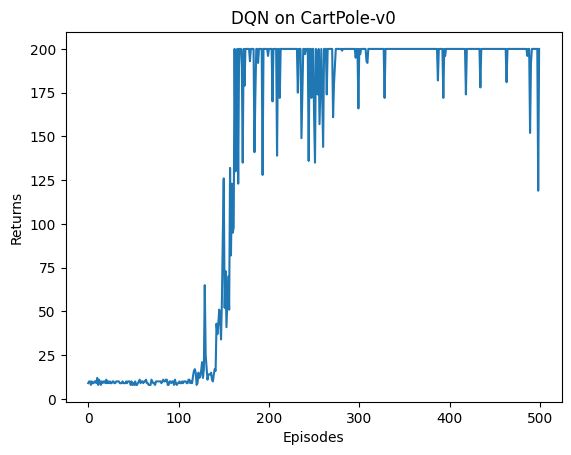

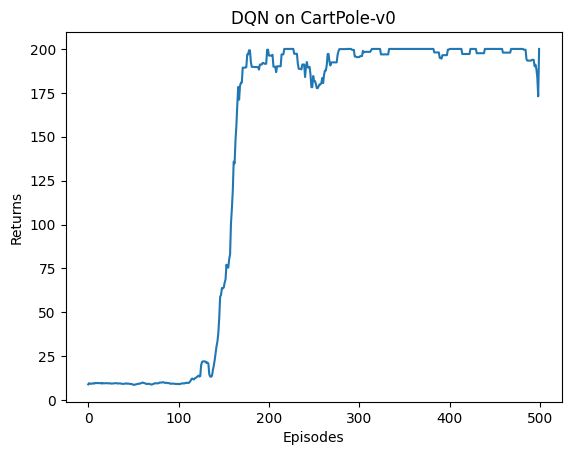

In [9]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()

mv_return = rl_utils.moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on {}'.format(env_name))
plt.show()